# Model training controls

In [21]:
import joblib
import optuna
import numpy as np
from pathlib import Path
import acm.observables.bgs as project

import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
study_dir = Path('/pscratch/sd/s/sbouchar/acm/bgs/trained_models/study/')
stat_name = 'tpcf'

## Stydy visualizations

### 1- TPCF

In [23]:
study = joblib.load(study_dir / f'{stat_name}.pkl')

In [24]:
optuna.visualization.plot_optimization_history(study)

In [25]:
optuna.visualization.plot_slice(study)

In [26]:
optuna.visualization.plot_param_importances(study)

In [27]:
optuna.visualization.plot_parallel_coordinate(study)

## Model errors

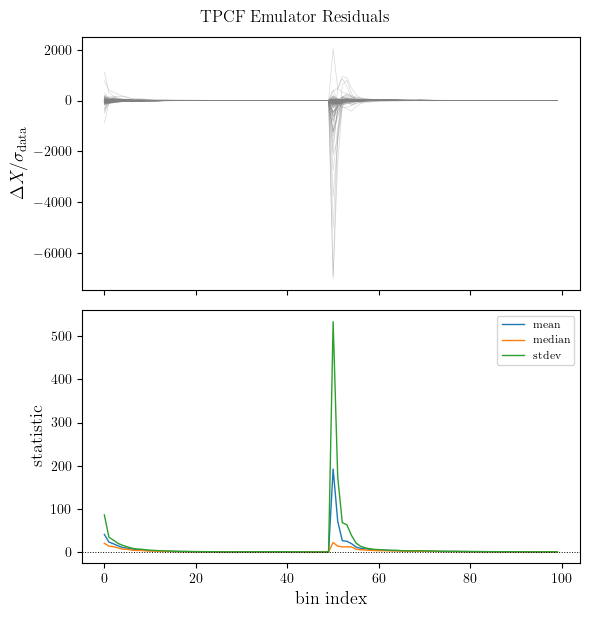

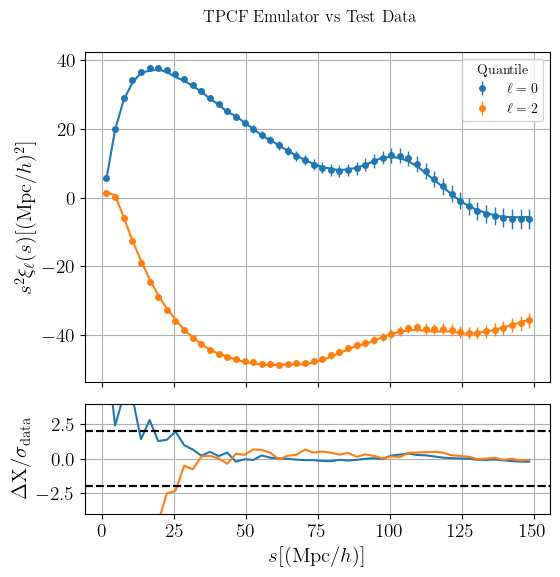

In [28]:
obs = getattr(project, stat_name)()
fig, ax = obs.plot_emulator_residuals(figsize=(6,6))
fig.suptitle(f'{stat_name.upper()} Emulator Residuals', y=1.02);

obs.select_filters = dict(cosmo_idx=0, hod_idx=0, ells=0)
fig, ax = obs.plot_observable(model_params=obs.x)
ax[0].legend(title='Quantile')
fig.suptitle(f'{stat_name.upper()} Emulator vs Test Data', y=0.95);